### Round 0 Analysis - Davide
Provide an analysis of both products, focusing mainly on TOMATOES since EMERALDS are just Market Making
I'll be adding log prices and log returns to the dataframe, moving on with the modelling of returns and other hypotheses

In [ ]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera

import prosperity4
from prosperity4.utils.dataloader import (
    load_trading_data,
    get_product_data,
    get_day_data,
    get_product_day_data,
    get_price_data,
    get_order_book_data,
    get_volume_data,
    convert_timestamp,
)

plt.style.use("dark_background")
sns.set_palette("pastel")

### Data Loading

In [ ]:
REPO_ROOT = Path(prosperity4.__file__).parents[1]
DATA_FOLDER = REPO_ROOT / "prosperity4" / "round0" / "data"
ROUND_NUM = 0
DAYS = [-2, -1]

data = load_trading_data(DATA_FOLDER, ROUND_NUM, DAYS)
prices_df = data.get("prices")
trades_df = data.get("trades")

print("Prices Shape :", prices_df.shape if prices_df is not None else None)
print("Trades Shape :", trades_df.shape if trades_df is not None else None)
print("\n--- Prices Head ---")
display(prices_df.head())
print("\n--- Trades Head ---")
display(trades_df.head())

Prices Shape : (40000, 17)
Trades Shape : (1219, 8)

--- Prices Head ---


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0



--- Trades Head ---


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2,-2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3,-2
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7,-2
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3,-2
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5,-2


### Splitting the datasets based on the products

In [ ]:
products = prices_df["product"].unique()

emeralds_prices_df = prices_df[prices_df["product"] == "EMERALDS"]
tomatoes_prices_df = prices_df[prices_df["product"] == "TOMATOES"]
emeralds_trades_df = trades_df[trades_df["symbol"] == "EMERALDS"]
tomatoes_trades_df = trades_df[trades_df["symbol"] == "TOMATOES"]

In [ ]:
'''
Here culo  we are copying the original dataframes, removing the buyer, seller and currency from the trades, summing if there are orders at the
same timestamp and price, then renaming the price and quantity column to market order price and quantity so we know these are bots trades,
then we are merging the 2 datasets so we have all the data on prices and volume, if at that timestamp there's a bot's trade, there's also the 
data for these trades.
At the end we are converting the timestamps so we have timestamp as index
'''
emeralds_trades = emeralds_trades_df.copy()
tomatoes_trades = tomatoes_trades_df.copy()

# Grouping and merging the EMERALDS so we only have 1 dataset containing both prices and trades, sorted by timestamp
emeralds_trades = emeralds_trades.drop(columns = ["buyer", "seller", "currency"])
emeralds_trades = emeralds_trades.groupby(["timestamp", "price", "day"], as_index = False).agg({"quantity": "sum"})
emeralds_trades = emeralds_trades.rename(columns = { 
                                        "price": "market order price",
                                        "quantity": "market order quantity"})
emeralds = emeralds_prices_df.merge(emeralds_trades[["timestamp", "market order price", "market order quantity", "day"]],
                                on = ["timestamp", "day"],
                                how = "left")

# Grouping and merging the EMERALDS so we only have 1 dataset containing both prices and trades, sorted by timestamp
tomatoes_trades = tomatoes_trades.drop(columns = ["buyer", "seller", "currency"])
tomatoes_trades = tomatoes_trades.groupby(["timestamp", "price", "day"], as_index = False).agg({"quantity": "sum"})
tomatoes_trades = tomatoes_trades.rename(columns = { 
                                        "price": "market order price",
                                        "quantity": "market order quantity"})
tomatoes = tomatoes_prices_df.merge(tomatoes_trades[["timestamp", "market order price", "market order quantity", "day"]],
                                on = ["timestamp", "day"],
                                how = "left")

# Convert to continuous timeframe so we don't have 2 separate days
emeralds = convert_timestamp(emeralds)
tomatoes = convert_timestamp(tomatoes)

emeralds.head()


,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,market order price,market order quantity,t
0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0,NaN,NaN,-3000000
1,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0,NaN,NaN,-2999900
2,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0,NaN,NaN,-2999800
3,EMERALDS,9992,13,9990,26,NaN,NaN,10008,13,10010,26,NaN,NaN,10000.0,0.0,NaN,NaN,-2999700
4,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0,NaN,NaN,-2999600


# Price and Trades plots

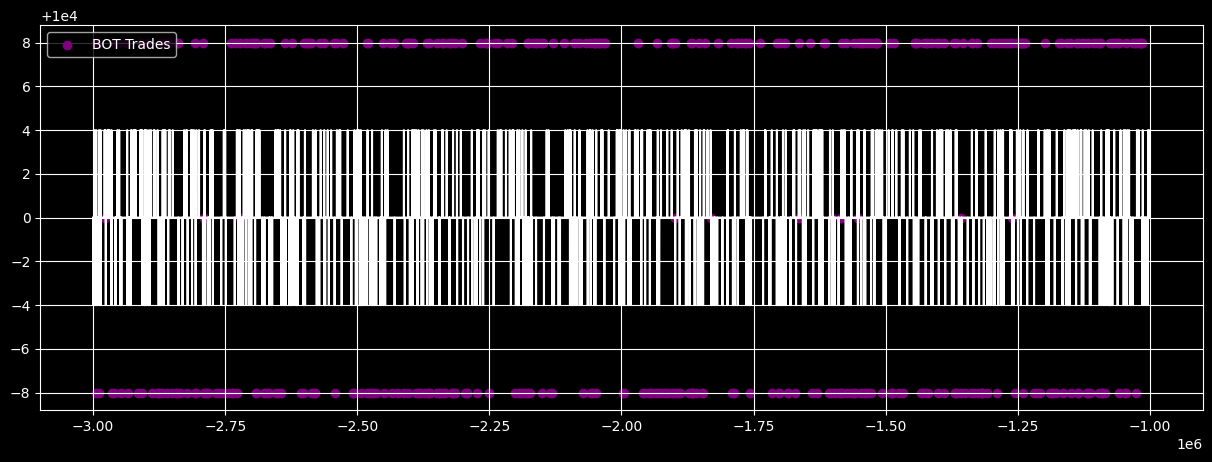

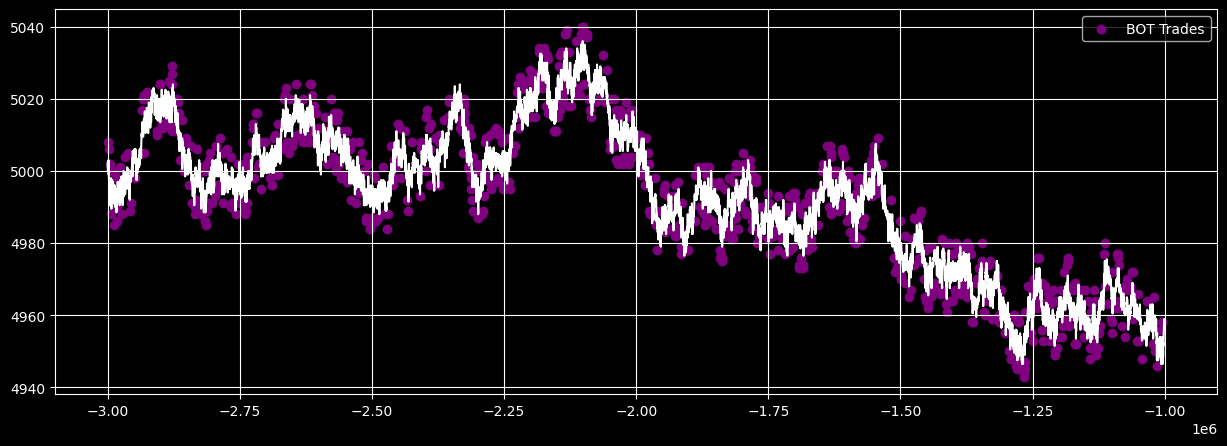

In [ ]:
# PLOTS OF PRICES
plt.figure(figsize = (15,5))
plt.plot(emeralds["t"], emeralds["mid_price"], color = "white")
plt.scatter(emeralds["t"], emeralds["market order price"], color = "purple", label = "BOT Trades")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize = (15,5))
plt.plot(tomatoes["t"], tomatoes["mid_price"], color = "white")
plt.scatter(tomatoes["t"], tomatoes["market order price"], color = "purple", label = "BOT Trades")
plt.grid(True)
plt.legend()
plt.show()

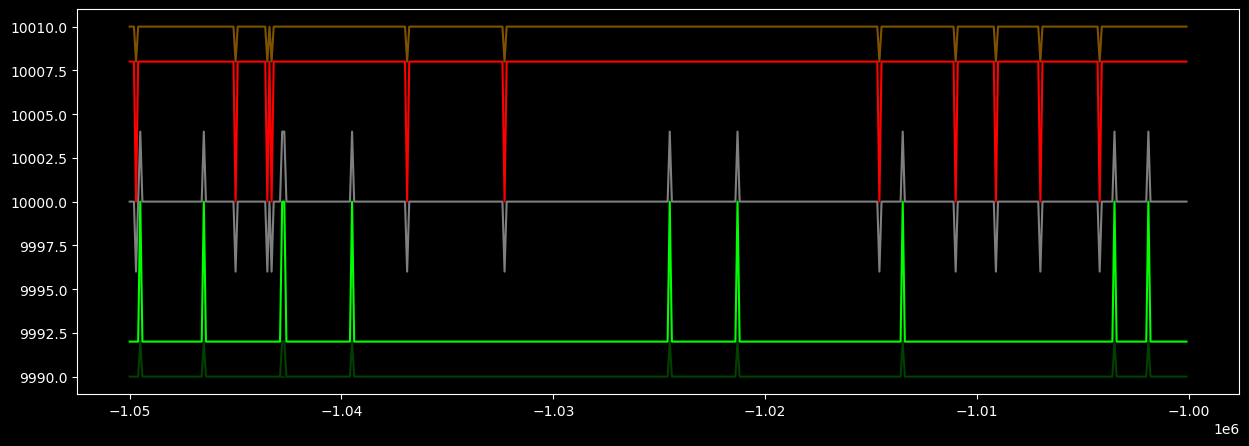

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(emeralds["t"][-500:], emeralds["mid_price"][-500:], color = "white", alpha = 0.5)
plt.plot(emeralds["t"][-500:], emeralds["ask_price_1"][-500:], color = "red", alpha = 1)
plt.plot(emeralds["t"][-500:], emeralds["ask_price_2"][-500:], color = "orange", alpha = 0.5)
plt.plot(emeralds["t"][-500:], emeralds["ask_price_3"][-500:], color = "salmon", alpha = 0.5)
plt.plot(emeralds["t"][-500:], emeralds["bid_price_1"][-500:], color = "lime", alpha = 1)
plt.plot(emeralds["t"][-500:], emeralds["bid_price_2"][-500:], color = "green", alpha = 0.5)
plt.plot(emeralds["t"][-500:], emeralds["bid_price_3"][-500:], color = "darkgreen", alpha = 0.5)
plt.show()

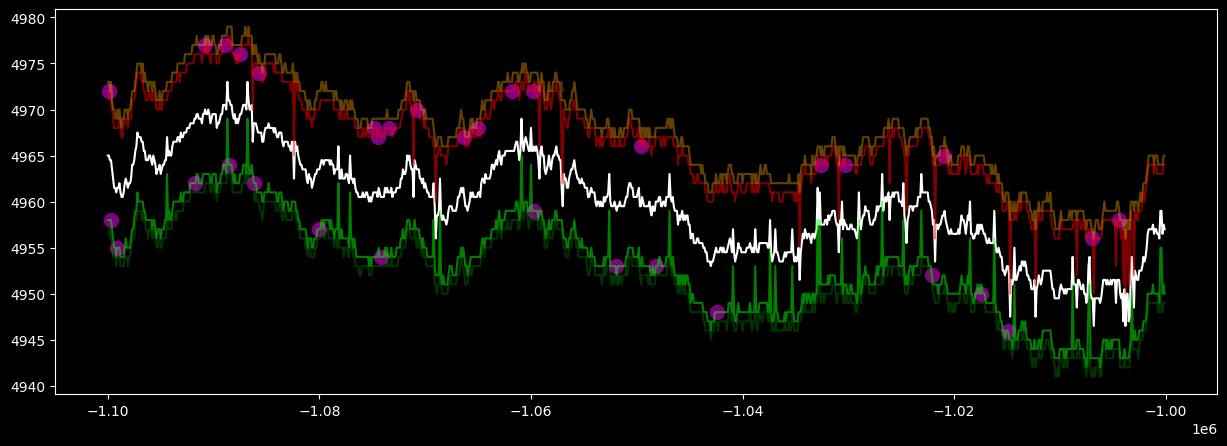

In [ ]:
# This considers the mid price
plt.figure(figsize=(15,5))
plt.plot(tomatoes["t"][-1000:], tomatoes["mid_price"][-1000:], color = "white", alpha = 1)
plt.plot(tomatoes["t"][-1000:], tomatoes["ask_price_1"][-1000:], color = "red", alpha = 0.5)
plt.plot(tomatoes["t"][-1000:], tomatoes["ask_price_2"][-1000:], color = "orange", alpha = 0.4)
plt.plot(tomatoes["t"][-1000:], tomatoes["ask_price_3"][-1000:], color = "salmon", alpha = 0.3)
plt.plot(tomatoes["t"][-1000:], tomatoes["bid_price_1"][-1000:], color = "lime", alpha = 0.5)
plt.plot(tomatoes["t"][-1000:], tomatoes["bid_price_2"][-1000:], color = "green", alpha = 0.4)
plt.plot(tomatoes["t"][-1000:], tomatoes["bid_price_3"][-1000:], color = "darkgreen", alpha = 0.4)
plt.scatter(tomatoes["t"][-1000:], tomatoes["market order price"][-1000:], color = "purple", alpha = 1, s = 100)
plt.show()

In [ ]:
bid_vol_cols   = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3']
bid_price_cols = ['bid_price_1',  'bid_price_2',  'bid_price_3']
ask_vol_cols   = ['ask_volume_1', 'ask_volume_2', 'ask_volume_3']
ask_price_cols = ['ask_price_1',  'ask_price_2',  'ask_price_3']

# idxmax(axis=1) returns the column name with the highest volume per row (NaN-safe)
bid_vol_winner = tomatoes[bid_vol_cols].idxmax(axis=1)
ask_vol_winner = tomatoes[ask_vol_cols].idxmax(axis=1)

# Map volume column name → corresponding price column name
bid_map = dict(zip(bid_vol_cols, bid_price_cols))
ask_map = dict(zip(ask_vol_cols, ask_price_cols))

# Row-wise lookup: for each row, read the price at the winning level
tomatoes['max_vol_bid_price'] = [tomatoes.at[idx, bid_map[col]] for idx, col in bid_vol_winner.items()]
tomatoes['max_vol_ask_price'] = [tomatoes.at[idx, ask_map[col]] for idx, col in ask_vol_winner.items()]

tomatoes["fv"] = (tomatoes["max_vol_bid_price"] + tomatoes["max_vol_ask_price"]) / 2

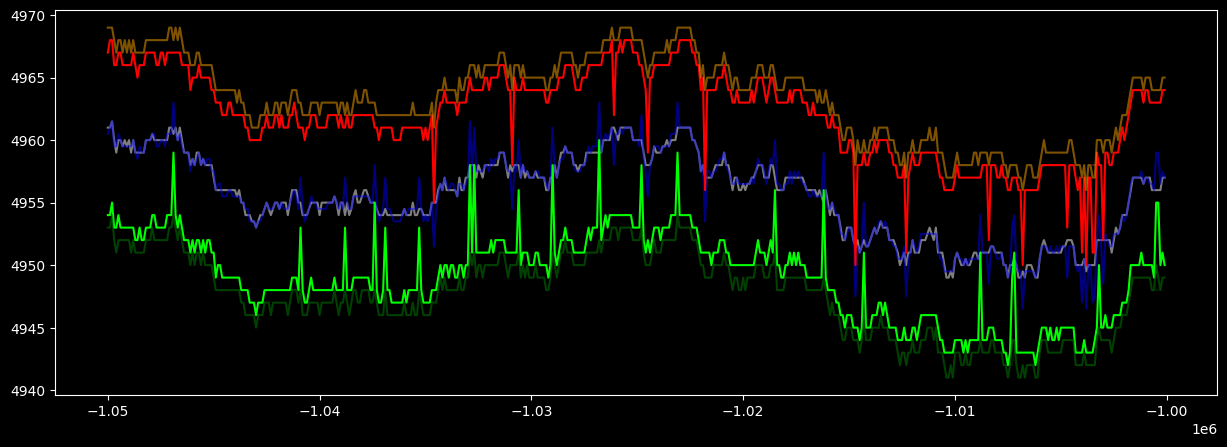

In [ ]:
# This considers the fv as the midpoint between max vol bid and ask
plt.figure(figsize=(15,5))
plt.plot(tomatoes["t"][-500:], tomatoes["fv"][-500:], color = "white", alpha = 0.5)
plt.plot(tomatoes["t"][-500:], tomatoes["mid_price"][-500:], color = "blue", alpha = 0.5)
plt.plot(tomatoes["t"][-500:], tomatoes["ask_price_1"][-500:], color = "red", alpha = 1)
plt.plot(tomatoes["t"][-500:], tomatoes["ask_price_2"][-500:], color = "orange", alpha = 0.5)
plt.plot(tomatoes["t"][-500:], tomatoes["ask_price_3"][-500:], color = "salmon", alpha = 0.25)
plt.plot(tomatoes["t"][-500:], tomatoes["bid_price_1"][-500:], color = "lime", alpha = 1)
plt.plot(tomatoes["t"][-500:], tomatoes["bid_price_2"][-500:], color = "green", alpha = 0.5)
plt.plot(tomatoes["t"][-500:], tomatoes["bid_price_3"][-500:], color = "darkgreen", alpha = 0.25)

### Volatility Arbitrage

In [ ]:
tomatoes["log_prices"] = np.log(tomatoes["mid_price"])
tomatoes["log_returns"] = tomatoes["log_prices"] - tomatoes["log_prices"].shift(1)
tomatoes.head()

,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,...,mid_price,profit_and_loss,market order price,market order quantity,t,max_vol_bid_price,max_vol_ask_price,fv,log_prices,log_returns
0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,...,5000.0,0.0,NaN,NaN,-3000000,4992.0,5008.0,5000.0,8.517193,NaN
1,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,...,5002.5,0.0,NaN,NaN,-2999900,4992.0,5008.0,5000.0,8.517693,0.0005
2,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,...,5001.0,0.0,NaN,NaN,-2999800,4993.0,5009.0,5001.0,8.517393,-0.0003
3,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,...,5001.5,0.0,NaN,NaN,-2999700,4993.0,5009.0,5001.0,8.517493,0.0001
4,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,...,5001.5,0.0,NaN,NaN,-2999600,4993.0,5009.0,5001.0,8.517493,0.0000


P-Value of ADF Test (H0: Non-Stationarity, H1: Stationarity): 0.0
P-Value of JB Test (H0: Normality, H1: Non-Normality): 0.0


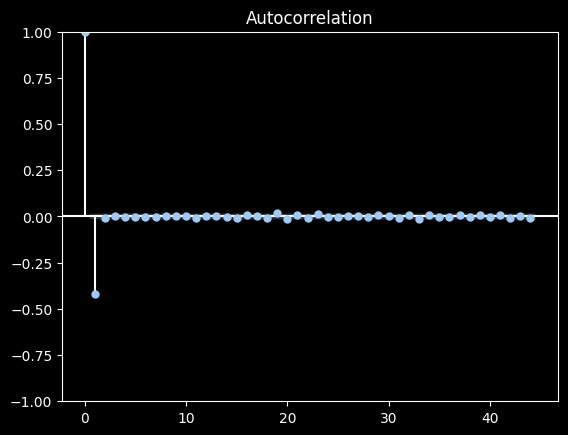

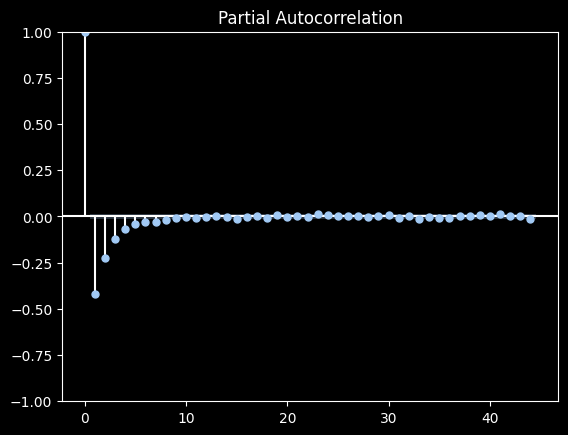

In [ ]:
# Log returns are stationary
print(f"P-Value of ADF Test (H0: Non-Stationarity, H1: Stationarity): {adfuller(tomatoes["log_returns"].dropna())[1]:.4}")

# ACF and PACF
plot_acf(tomatoes["log_returns"].dropna())
plot_pacf(tomatoes["log_returns"].dropna())

# Normality
print(f"P-Value of JB Test (H0: Normality, H1: Non-Normality): {jarque_bera(tomatoes["log_returns"].dropna())[1]:.4}")

### ARIMA MODELLING

Continue this and see if it is profitable

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(tomatoes["log_returns"].dropna(), order = [1,0,0]).fit()
model.summary()

d:\IMC Prosperity 4\imc-prosperity-4\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            log_returns   No. Observations:                20000
Model:                 ARIMA(1, 0, 0)   Log Likelihood              138005.588
Date:                Thu, 09 Apr 2026   AIC                        -276005.176
Time:                        22:28:11   BIC                        -275981.466
Sample:                             0   HQIC                       -275997.419
                              - 20000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.319e-07   1.22e-06     -0.354      0.723   -2.82e-06    1.96e-06
ar.L1         -0.4197      0.004    -99.235      0.000      -0.428      -0.411
sigma2      5.942e-08   3.58e-10    165.948      0.000    5.87e-08    6.01e-08
===================================================================================
Ljung-Box (L1) (Q):                 179.89   Jarque-Bera (JB):             10908.41
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.03   Skew:                            -0.21
Prob(H) (two-sided):                  0.26   Kurtosis:                         6.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Z SCORE ANALYSIS

$z = \frac{x - \mu}{\sigma}$

In [ ]:
tomatoes["40_EMA"] = tomatoes["mid_price"].ewm(span = 40).mean()
tomatoes["20_EMA"] = tomatoes["mid_price"].ewm(span = 20).mean()

tomatoes["Z_40"] = (tomatoes["mid_price"] - tomatoes["40_EMA"]) / tomatoes["mid_price"].rolling(window = 100).std()


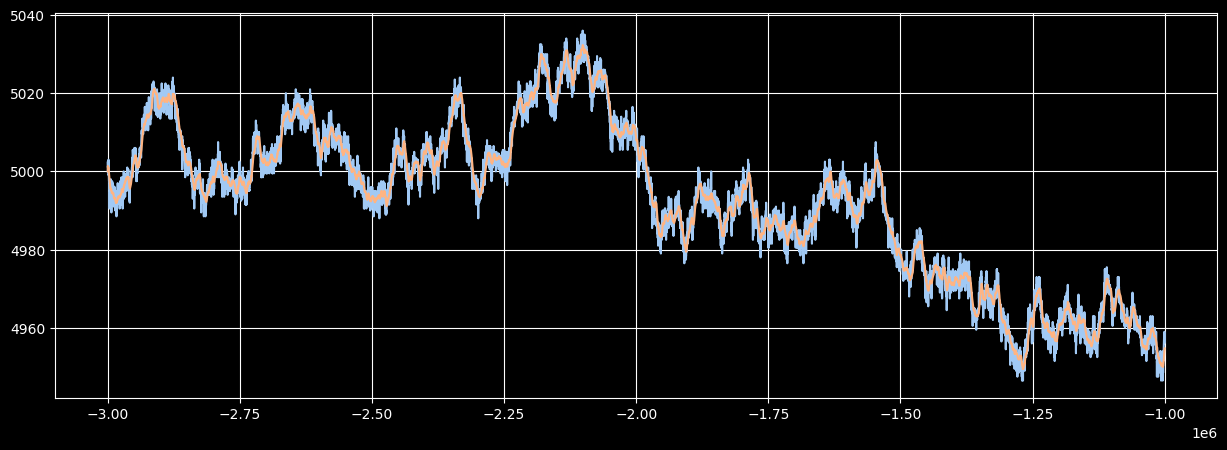

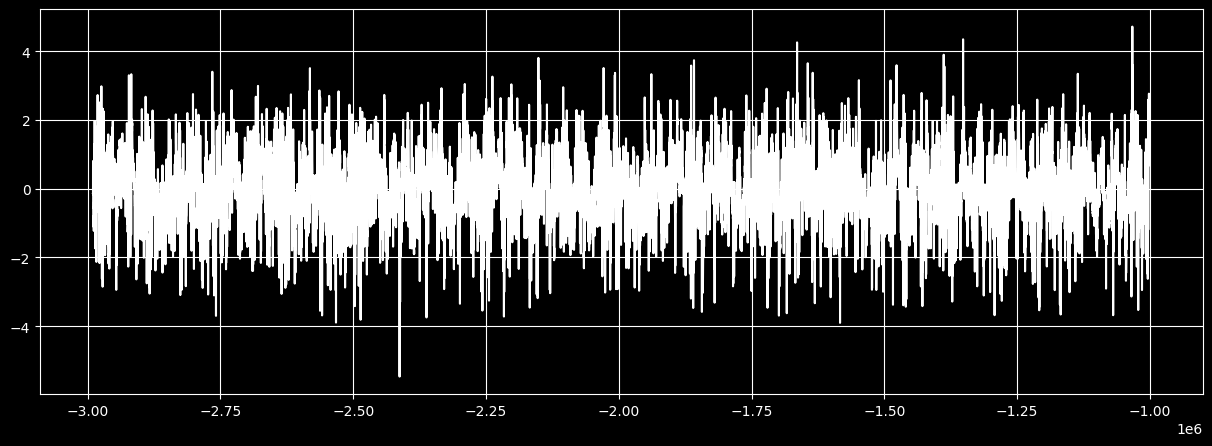

In [ ]:
plt.figure(figsize = (15,5))
plt.plot(tomatoes["t"], tomatoes["mid_price"])
plt.plot(tomatoes["t"], tomatoes["40_EMA"])
plt.grid(True)
plt.show()

plt.figure(figsize = (15,5))
plt.plot(tomatoes["t"], tomatoes["Z_40"], color = "white")
plt.grid(True)
plt.show()